In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Преобработка данных

In [2]:
META_DIR = '/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata'
META_DIR2 = '/kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_small/fma_small'
track = f'{META_DIR}/tracks.csv'

Источник: https://www.kaggle.com/code/titeohihi/fma-ml-training

In [12]:
data = pd.read_csv(track, index_col=0, header=[0, 1])

In [13]:
data

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   
...           ...                  ...                  ...      ...   
155316          0  2017-03-30 15:20:35  2017-02-17 00:00:00      NaN   
155317          0  2017-03-30 15:20:35  2017-02-17 00:00:00      NaN   
155318          0  2017-03-30 15:20:35  2017-02-17 00:00:00      NaN   
155319          0  2017-03-30 15:20:35  2017-02-17 00:00:00      NaN   
155320          0  2017-03-26 16:22:18  2017-03-26 00:00:00      NaN   

                                                                              \
         favorites     id                                        information   
track_id                                                                       
2                4      1                                            <p></p>   
3                4      1                                            <p></p>   
5                4      1                                            <p></p>   
10               4      6                                                NaN   
20               2      4          <p> "spiritual songs" from Nicky Cook</p>   
...            ...    ...                                                ...   
155316           0  22940  <p>A live performance at Monty Hall on Feb 17,...   
155317           0  22940  <p>A live performance at Monty Hall on Feb 17,...   
155318           0  22940  <p>A live performance at Monty Hall on Feb 17,...   
155319           0  22940  <p>A live performance at Monty Hall on Feb 17,...   
155320           1  22906                                                NaN   

                               \
         listens     producer   
track_id                        
2           6073          NaN   
3           6073          NaN   
5           6073          NaN   
10         47632          NaN   
20          2710          NaN   
...          ...          ...   
155316      1506  Monty Hall    
155317      1506  Monty Hall    
155318      1506  Monty Hall    
155319      1506  Monty Hall    
155320      7481          NaN   

                                                             ...       track  \
                                                       tags  ... information   
track_id                                                     ...               
2                                                        []  ...         NaN   
3                                                        []  ...         NaN   
5                                                        []  ...         NaN   
10                                                       []  ...         NaN   
20                                                       []  ...         NaN   
...                                                     ...  ...         ...   
155316                                                   []  ...         NaN   
155317                                                   []  ...         NaN   
155318                                                   []  ...         NaN   
155319                                                   []  ...         NaN   
155320    ['ballad', 'epic', 'rockabilly', 'curse', 'hex...  ...         NaN   

                                 \
         interest language_code   
track_id                          
2            4656            en   
3            1470            en   
5            1933            en   
10          54881            en   
20            978            en   
...           ... 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106574 entries, 2 to 155320
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   (album, comments)            106574 non-null  int64  
 1   (album, date_created)        103045 non-null  object 
 2   (album, date_released)       70294 non-null   object 
 3   (album, engineer)            15295 non-null   object 
 4   (album, favorites)           106574 non-null  int64  
 5   (album, id)                  106574 non-null  int64  
 6   (album, information)         83149 non-null   object 
 7   (album, listens)             106574 non-null  int64  
 8   (album, producer)            18060 non-null   object 
 9   (album, tags)                106574 non-null  object 
 10  (album, title)               105549 non-null  object 
 11  (album, tracks)              106574 non-null  int64  
 12  (album, type)                100066 non-null  object 
 13  (art

В первую очередь, мы заметили, что у нас есть разные уровни обращения к переменным, что весьма неудобно, в дальнейшем будут проблемы с построением графиков и тд

In [14]:
col = []
for i in data.columns:
    col.append(''.join(i)) # соединяем верхний уровень с нижним
data.columns = col

Источник: https://thecode.media/metod-join-v-python/

Теперь у нас колонки называются albumcomments, например

In [15]:
data

,albumcomments,albumdate_created,albumdate_released,albumengineer,albumfavorites,albumid,albuminformation,albumlistens,albumproducer,albumtags,...,trackinformation,trackinterest,tracklanguage_code,tracklicense,tracklistens,tracklyricist,tracknumber,trackpublisher,tracktags,tracktitle
track_id,,,,,,,,,,,,,,,,,,,,,
2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
10,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,[],...,NaN,54881,en,Attribution-NonCommercial-NoDerivatives (aka M...,50135,NaN,1,NaN,[],Freeway
20,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,[],...,NaN,978,en,Attribution-NonCommercial-NoDerivatives (aka M...,361,NaN,3,NaN,[],Spiritual Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155316,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,[],...,NaN,122,NaN,Creative Commons Attribution-NonCommercial-NoD...,102,NaN,3,NaN,[],The Auger
155317,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,[],...,NaN,194,NaN,Creative Commons Attribution-NonCommercial-NoD...,165,NaN,4,NaN,[],Let's Skin Ruby
155318,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,[],...,NaN,214,NaN,Creative Commons Attribution-NonCommercial-NoD...,168,NaN,6,NaN,[],My House Smells Like Kim Deal/Pulp


Сделаем reset_index(), чтобы track_id был не id, а столбцом

In [16]:
data = data.reset_index()

Источник: https://sky.pro/wiki/media/sbros-indeksa-v-pandas-dataframe/

In [17]:
data

,track_id,albumcomments,albumdate_created,albumdate_released,albumengineer,albumfavorites,albumid,albuminformation,albumlistens,albumproducer,...,trackinformation,trackinterest,tracklanguage_code,tracklicense,tracklistens,tracklyricist,tracknumber,trackpublisher,tracktags,tracktitle
0,2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
1,3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
2,5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
3,10,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,...,NaN,54881,en,Attribution-NonCommercial-NoDerivatives (aka M...,50135,NaN,1,NaN,[],Freeway
4,20,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,...,NaN,978,en,Attribution-NonCommercial-NoDerivatives (aka M...,361,NaN,3,NaN,[],Spiritual Level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106569,155316,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,122,NaN,Creative Commons Attribution-NonCommercial-NoD...,102,NaN,3,NaN,[],The Auger
106570,155317,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,194,NaN,Creative Commons Attribution-NonCommercial-NoD...,165,NaN,4,NaN,[],Let's Skin Ruby
106571,155318,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,214,NaN,Creative Commons Attribution-NonCommercial-NoD...,168,NaN,6,NaN,[],My House Smells Like Kim Deal/Pulp
106572,155319,0,2017-03-30 15:20:35,2017-02-17 00:00:00,NaN,0,22940,"<p>A live performance at Monty Hall on Feb 17,...",1506,Monty Hall,...,NaN,336,NaN,Creative Commons Attribution-NonCommercial-NoD...,294,NaN,5,NaN,[],The Man With Two Mouths


Теперь мы сможем обращаться к датасету как обычно

In [18]:
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106574 entries, 0 to 106573
Data columns (total 53 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   track_id                 106574 non-null  int64  
 1   albumcomments            106574 non-null  int64  
 2   albumdate_created        103045 non-null  object 
 3   albumdate_released       70294 non-null   object 
 4   albumengineer            15295 non-null   object 
 5   albumfavorites           106574 non-null  int64  
 6   albumid                  106574 non-null  int64  
 7   albuminformation         83149 non-null   object 
 8   albumlistens             106574 non-null  int64  
 9   albumproducer            18060 non-null   object 
 10  albumtags                106574 non-null  object 
 11  albumtitle               105549 non-null  object 
 12  albumtracks              106574 non-null  int64  
 13  albumtype                100066 non-null  object 
 14  arti

Дубликатов нет и при этом в каждой строке есть пропуски.

EDA

Посмотрим какого года у нас музыка.

In [19]:
data['year'] = pd.to_datetime(data['albumdate_released']).dt.strftime('%Y')

Источник: https://sky.pro/wiki/python/poluchenie-tekuschego-goda-i-mesyatsa-v-python-datetime/

In [13]:
df = data['year'].value_counts().sort_index()

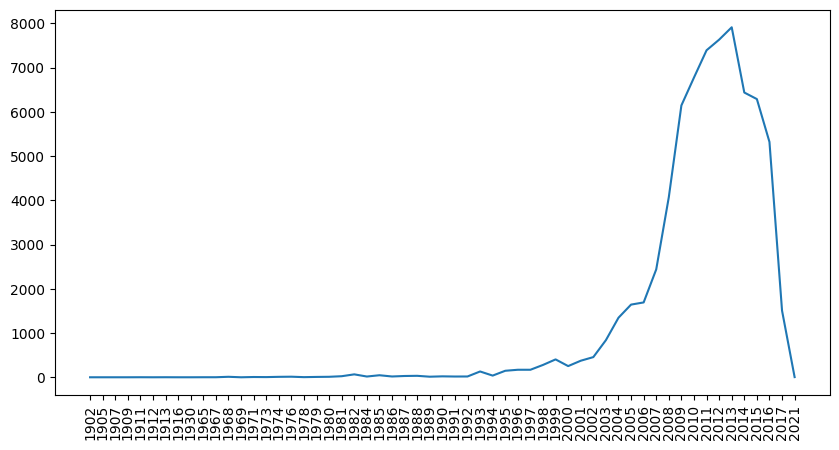

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df.values)
plt.xticks(rotation ='vertical')
plt.show()

В нашем датасете в основном песни 2013 года

Рассмотрим какие жанры чаще всегог встречаются в нашем датасете

In [20]:
df1 = data['trackgenre_top'].value_counts()
df1

trackgenre_top
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

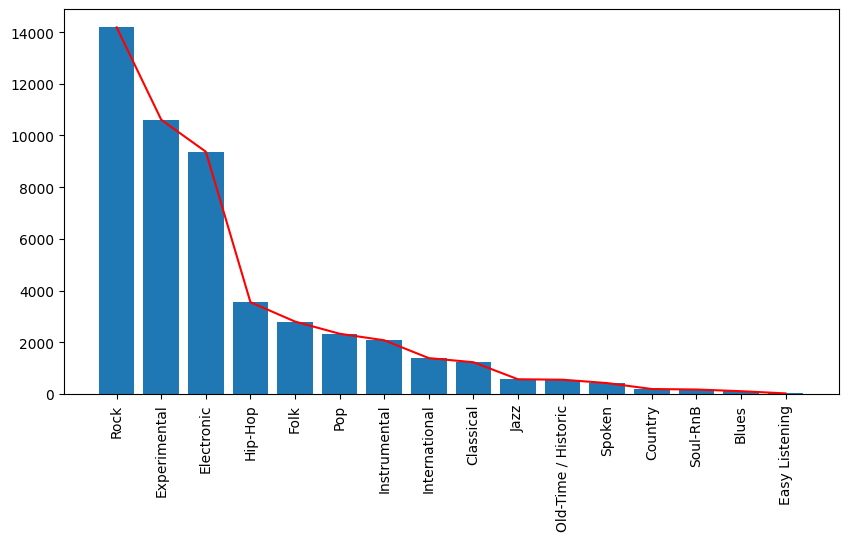

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(df1.index, df1.values)
plt.plot(df1.index, df1.values, color='red')
plt.xticks(rotation ='vertical')
plt.show()

В основном у нас рок композиции

Рассмотрим из каких стран у нас в основном треки

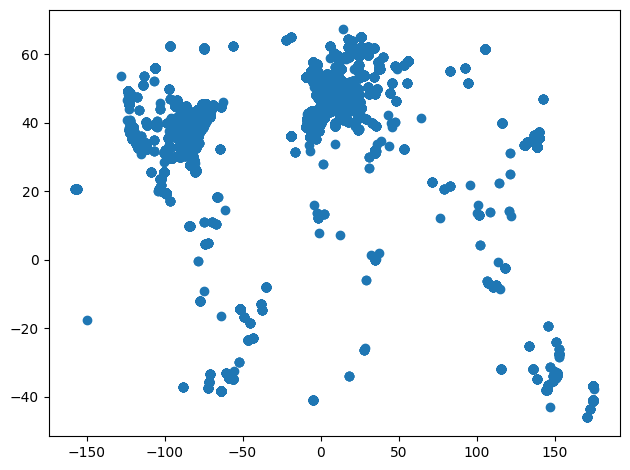

In [35]:
plt.scatter(x = data['artistlongitude'], y = data['artistlatitude'])
plt.tight_layout()
plt.show()

В основном у нас исполнители из Европы и США

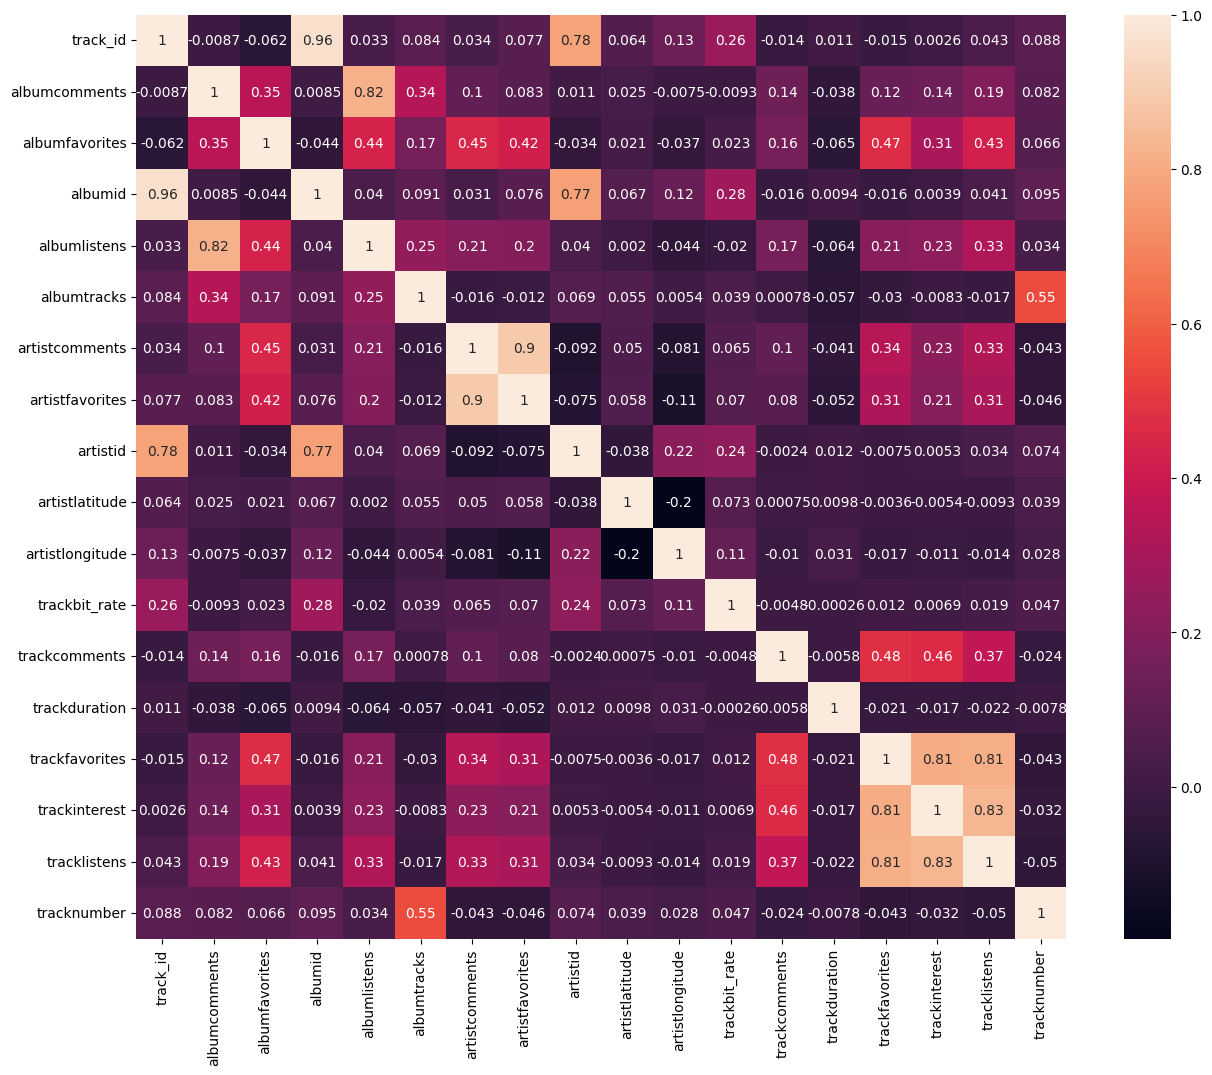

In [51]:
plt.figure(figsize=(15, 12))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.show()

Источник: https://sky.pro/wiki/python/vybor-chislovykh-stolbtsov-v-pandas-funktsiya-is-numeric/

Высокая корреляцию у track_id с albumid и artistid, но это скорее случайность, чем зависимость. Скорее всего нумерацию присваивали просто подряд.

Можно выявит зависимость, чем популярнее артист, тем больше у него комментариев (0.9). Аналогичная история с треками чем больше интерес к треку, тем больше прослушиваний. 

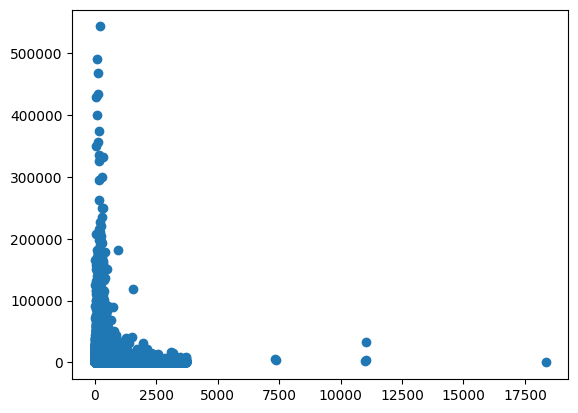

In [58]:
plt.scatter(x = data['trackduration'], y = data['tracklistens'])
plt.show()

У нас в датасете в основном, короткие треки самые прослушиваемые. 

Далее будем концетрироваться именно на звуке, поэтому насчем с подготовки данных (создание спектрограммы)